In [28]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt #uv pip install matplotlib
from torch.nn import Conv2d
import numpy as np

In [29]:
# 1. 读取图片
img = plt.imread(r"D:\huanghoulin\teacher_uv_dl_py39_20260815\data\duck.jpg")
print(img.shape)

(1080, 1080, 3)


In [30]:
# 2. 转换tensor  (h, w, c) => (c,h,w)
input = torch.tensor(img).permute(2, 0, 1).float()

print(input.shape)

torch.Size([3, 1080, 1080])


In [31]:
# 3. 定义卷积层
# out_channels=输出通道 决定卷积核的个数
# kernel_size=3 卷积核的大小 3 表示 3*3的卷积核
# stride =步长  默认=1
# padding = 填充 默认=0
# 311 后大小不变
conv = Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)

In [32]:
# 4.向前传播: 做卷积
output = conv(input.unsqueeze(0))  # 加上这步，CPU和GPU都通用
print(output.shape)

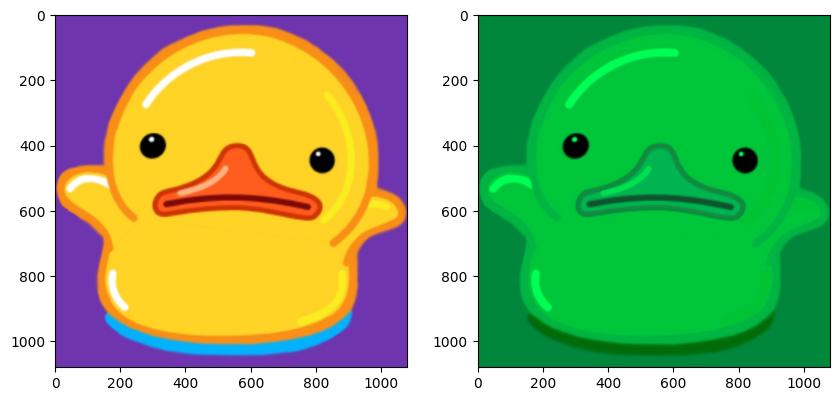

In [33]:
# 显示2个图片

# 显示原始图片
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)

# 显示处理后的图片
# 1. squeeze(0): 去掉前面那个 1，变成 [3, 1080, 1080]
# 2. permute(1, 2, 0): 转换通道，变成 [1080, 1080, 3]
# 3. detach().cpu().numpy(): 从 GPU (如果有) 移到 CPU 并转成 numpy
out_img = output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

# 4. 截断数值到 0-255，并转成 uint8 整数格式 (否则 imshow 可能显示一片白)
out_img = np.clip(out_img, 0, 255).astype(np.uint8)

# 5. 现在再显示
ax[1].imshow(out_img)